<div style="background-color:#4A235A; padding:15px; border-radius:8px;">
<h1 style="color:white; text-align:center;">
🏎 Exploratory Data Analysis - USA Cars Dataset
</h1>
</div>

# 📓 Import Libraries

In [40]:
#Import Libraries
print('📥 Libraries imported successfully')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

📥 Libraries imported successfully


# 🔎 Reading Dataset

In [41]:
#Reading Dataset
print('📥 Loading the Dataset')
data = pd.read_csv('USA_cars_datasets.csv')

📥 Loading the Dataset


In [39]:
#first 5 Rows of Dataset
print('📄 Display the first 5 Rows of Dataset')
df = data.copy()
df.head()

📄 Display the first 5 Rows of Dataset


,Unnamed: 0,price,brand,model,year,title_status,mileage,color,vin,lot,state,country,condition
0,0,6300,toyota,cruiser,2008,clean vehicle,274117.0,black,jtezu11f88k007763,159348797,new jersey,usa,10 days left
1,1,2899,ford,se,2011,clean vehicle,190552.0,silver,2fmdk3gc4bbb02217,166951262,tennessee,usa,6 days left
2,2,5350,dodge,mpv,2018,clean vehicle,39590.0,silver,3c4pdcgg5jt346413,167655728,georgia,usa,2 days left
3,3,25000,ford,door,2014,clean vehicle,64146.0,blue,1ftfw1et4efc23745,167753855,virginia,usa,22 hours left
4,4,27700,chevrolet,1500,2018,clean vehicle,6654.0,red,3gcpcrec2jg473991,167763266,florida,usa,22 hours left


# 📑 Dataset Overview

In [72]:
#Shape of the Dataset
print('📐 The Shape of the Dataset :  ',df.shape)

📐 The Shape of the Dataset :   (2499, 13)


In [323]:
# Checking the variables/columns and null values
print('📋 Dataset Information : ')
df.info()

📋 Dataset Information : 
<class 'pandas.core.frame.DataFrame'>
Index: 2456 entries, 0 to 2498
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   price         2456 non-null   int64  
 1   brand         2456 non-null   object 
 2   model         2456 non-null   object 
 3   year          2456 non-null   int64  
 4   title_status  2456 non-null   object 
 5   mileage       2456 non-null   float64
 6   color         2456 non-null   object 
 7   state         2456 non-null   object 
 8   country       2456 non-null   object 
 9   condition     2456 non-null   object 
 10  is_outlier    2456 non-null   bool   
dtypes: bool(1), float64(1), int64(2), object(7)
memory usage: 213.5+ KB


In [57]:
# Columns Names
print('📝 Columns Names : ')
print( df.columns.tolist()) #change it to list

📝 Columns Names : 
['Unnamed: 0', 'price', 'brand', 'model', 'year', 'title_status', 'mileage', 'color', 'vin', 'lot', 'state', 'country', 'condition']


In [204]:
#Describe statistics for numerical columns
print('🔦 Describe Statistics (Numerical) : ')
df.describe().T

🔦 Describe Statistics (Numerical) : 


,count,mean,std,min,25%,50%,75%,max
price,2456.0,19096.258550,11962.176006,25.0,10500.00,17050.0,25800.00,84900.0
year,2456.0,2016.931189,2.957497,1973.0,2016.00,2018.0,2019.00,2020.0
mileage,2456.0,50111.425081,54604.463791,0.0,21276.75,35048.5,60050.75,1017936.0


In [134]:
#Describe statistics for Categorical columns
print('🔦 Describe Statistics (Categorical) :')
df.describe(include='O').T

🔦 Describe Statistics (Categorical) :


,count,unique,top,freq
brand,2499,28,ford,1235
model,2499,127,door,651
title_status,2499,2,clean vehicle,2336
color,2499,49,white,707
state,2499,44,pennsylvania,299
country,2499,2,usa,2492
condition,2499,47,2 days left,832


In [74]:
#Data types of each column
print('❔ Data Types of each column : ')
df.dtypes

❔ Data Types of each column : 


Unnamed: 0        int64
price             int64
brand            object
model            object
year              int64
title_status     object
mileage         float64
color            object
vin              object
lot               int64
state            object
country          object
condition        object
dtype: object

In [105]:
# Unique Values in Each Column
print('Unique Values in Each Column :' , df.nunique())

Unique Values in Each Column : Unnamed: 0      2499
price            790
brand             28
model            127
year              30
title_status       2
mileage         2439
color             49
vin             2495
lot             2495
state             44
country            2
condition         47
dtype: int64


# 🧹 Data Cleaning

In [129]:
# Check for Missing Values
print('❕ Missing Values : ')
print(df.isnull().sum())
print ('✅ No Missing Values')

❕ Missing Values : 
price           0
brand           0
model           0
year            0
title_status    0
mileage         0
color           0
state           0
country         0
condition       0
dtype: int64
✅ No Missing Values


In [130]:
# Check for Duplicates Rows 
print('🔂 Number of Duplicate Rows = ' , df.duplicated().sum())

🔂 Number of Duplicate Rows =  0


In [131]:
# Check for Duplicates Columns 
print('🔂 Number of Duplicate Columns  = ' , df.T.duplicated().sum())

🔂 Number of Duplicate Columns  =  0


In [126]:
# Removing Unnecessary Columns (Unnamed: 0 , vin , lot)
print('❌ Columns Deleted')
df.drop(columns=['Unnamed: 0'], inplace=True)
df.drop(columns=['vin'], inplace=True)
df.drop(columns=['lot'], inplace=True)

❌ Columns Deleted


In [128]:
# After Removing Unnecessary Columns
df.head()

,price,brand,model,year,title_status,mileage,color,state,country,condition
0,6300,toyota,cruiser,2008,clean vehicle,274117.0,black,new jersey,usa,10 days left
1,2899,ford,se,2011,clean vehicle,190552.0,silver,tennessee,usa,6 days left
2,5350,dodge,mpv,2018,clean vehicle,39590.0,silver,georgia,usa,2 days left
3,25000,ford,door,2014,clean vehicle,64146.0,blue,virginia,usa,22 hours left
4,27700,chevrolet,1500,2018,clean vehicle,6654.0,red,florida,usa,22 hours left


In [181]:
# Handling Zeros Prices 
df = df[df['price'] > 0]

# 📊 EDA

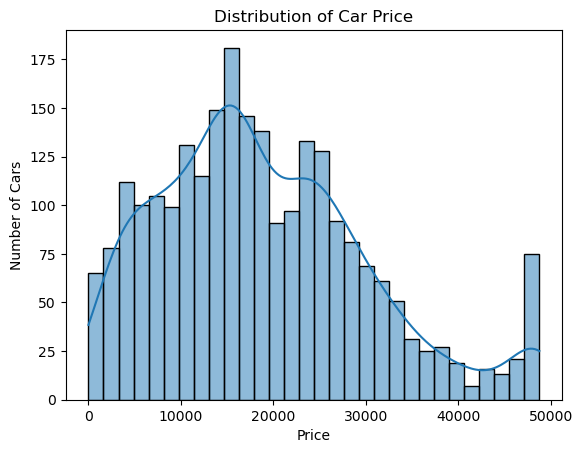

In [230]:
# Price Distribution (with outliers)
sns.histplot(df['price'] , bins=30 , kde=True)
plt.title('Distribution of Car Price')
plt.xlabel('Price')
plt.ylabel('Number of Cars')
plt.show()

In [207]:
# Calculate Outliers
print('⚠️ Calculate Outliers')
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
print('Q1 =' , Q1)
print('Q3 =' , Q3)
print('IQR =' , IQR)

⚠️ Calculate Outliers
Q1 = 10500.0
Q3 = 25800.0
IQR = 15300.0


In [213]:
# Outliers Limits
print('🔴 Outliers Limits')
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print('Lower = ' ,lower)
print('Upper = ' ,upper)

🔴 Outliers Limits
Lower =  -12450.0
Upper =  48750.0


In [224]:
# Outliers
df['is_outlier'] = (df['price'] < lower) | (df['price'] > upper)
df.head()

,price,brand,model,year,title_status,mileage,color,state,country,condition,is_outlier
0,6300,toyota,cruiser,2008,clean vehicle,274117.0,black,new jersey,usa,10 days left,False
1,2899,ford,se,2011,clean vehicle,190552.0,silver,tennessee,usa,6 days left,False
2,5350,dodge,mpv,2018,clean vehicle,39590.0,silver,georgia,usa,2 days left,False
3,25000,ford,door,2014,clean vehicle,64146.0,blue,virginia,usa,22 hours left,False
4,27700,chevrolet,1500,2018,clean vehicle,6654.0,red,florida,usa,22 hours left,False


In [233]:
# Handling Outliers
df['price'] = df['price'].clip(lower , upper)

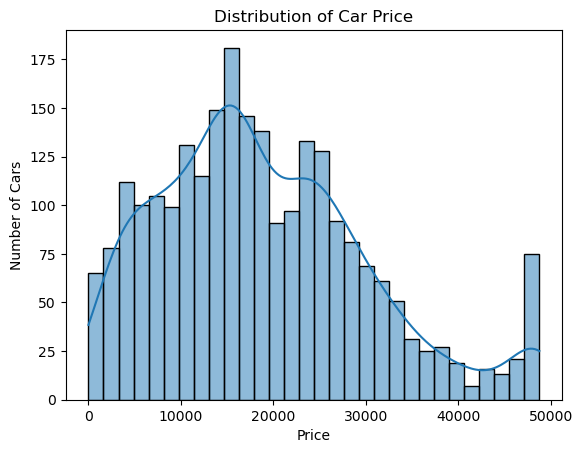

In [231]:
# Price Distribution 
sns.histplot(df['price'] , bins=30 , kde=True)
plt.title('Distribution of Car Price')
plt.xlabel('Price')
plt.ylabel('Number of Cars')
plt.show()

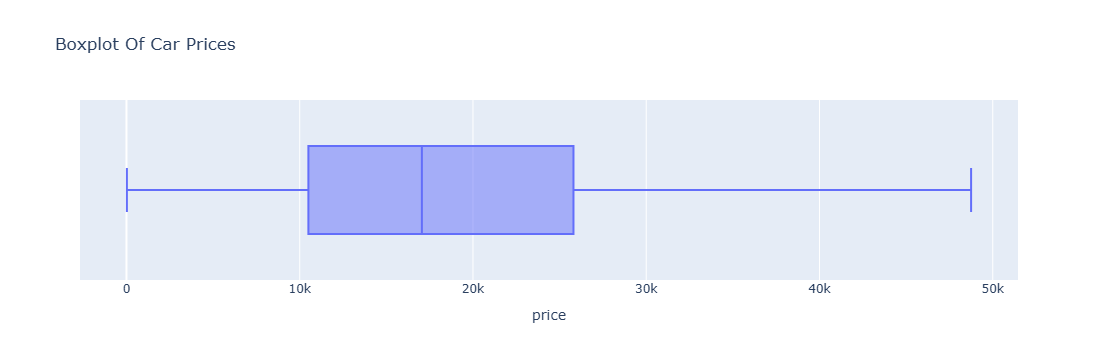

In [232]:
# Check Outliers (Price)
fig = px.box(df , x='price' , title='Boxplot Of Car Prices') 
fig.show()

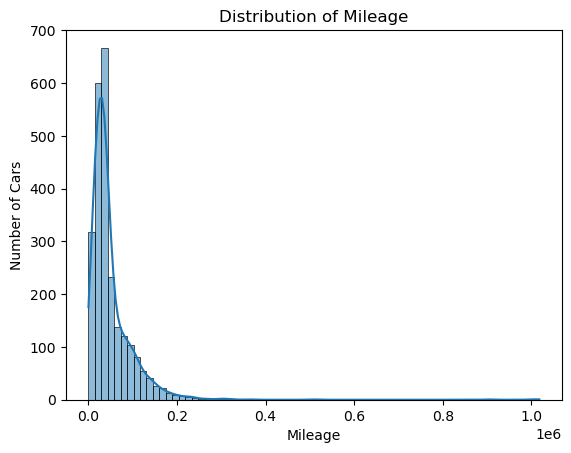

In [183]:
# Mileage Distribution 
sns.histplot(df['mileage'] , bins=70 , kde=True)
plt.title('Distribution of Mileage')
plt.xlabel('Mileage')
plt.ylabel('Number of Cars')
plt.show()

In [241]:
# Q1 : What is the Average Price of cars?
avg_price = round(df['price'].mean(),2)
print ('Average car Price : ' , avg_price)

Average car Price :  18914.32


In [243]:
# Q2 : What is the Average Mileage of cars?
avg_mileage = round(df['mileage'].mean(),2)
print ('Average Mileage : ' , avg_mileage)

Average Mileage :  50111.43


In [248]:
# Q3 : Average Price per Brand 
avg_price_brand = df.groupby('brand')['price'].mean().sort_values(ascending=False)
avg_price_brand

brand
harley-davidson    48750.000000
lincoln            36300.000000
maserati           30300.000000
lexus              29795.000000
land               28900.000000
cadillac           27712.222222
bmw                26971.875000
mercedes-benz      25089.000000
ford               21726.658176
buick              21358.750000
chevrolet          19276.314685
audi               18641.666667
dodge              17791.439535
mazda              16000.000000
chrysler           13686.111111
infiniti           13098.333333
nissan             12065.820513
kia                12050.833333
gmc                11190.250000
ram                11050.000000
jeep               10933.833333
acura               7266.666667
honda               6684.545455
toyota              6300.000000
hyundai             5203.200000
heartland           3707.500000
jaguar              2800.000000
peterbilt            533.333333
Name: price, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

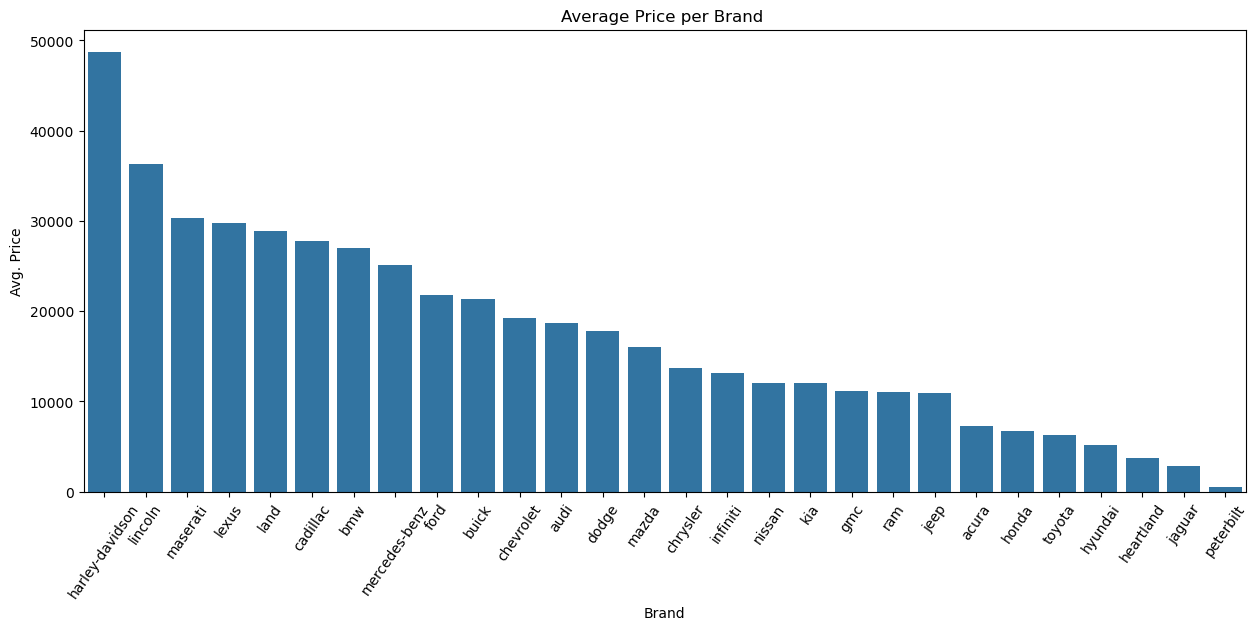

In [279]:
# Use Barplot
plt.figure(figsize=(15 , 6))

sns.barplot(x=avg_price_brand.index ,
y = avg_price_brand.values)
plt.xticks(rotation = 55)
plt.title('Average Price per Brand ')
plt.xlabel('Brand')
plt.ylabel('Avg. Price')

plt.show

In [275]:
# Q4 : Avreage Mileage per Brand
avg_mileage_brand = df.groupby('brand')['mileage'].mean().sort_values(ascending = False)
avg_mileage_brand

brand
peterbilt          639992.333333
toyota             274117.000000
acura              120379.666667
audi                96822.666667
honda               86052.727273
chrysler            73004.000000
chevrolet           60603.066434
hyundai             56683.866667
gmc                 55592.475000
mercedes-benz       54597.000000
ford                50436.972062
kia                 48955.000000
mazda               47753.000000
dodge               43688.960465
nissan              42426.230769
jeep                38723.266667
bmw                 37295.750000
maserati            37021.000000
cadillac            32976.666667
ram                 30421.000000
buick               29632.083333
land                26613.750000
infiniti            25023.166667
lexus               22391.000000
jaguar              20849.000000
lincoln             14541.000000
harley-davidson      9502.000000
heartland               1.000000
Name: mileage, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

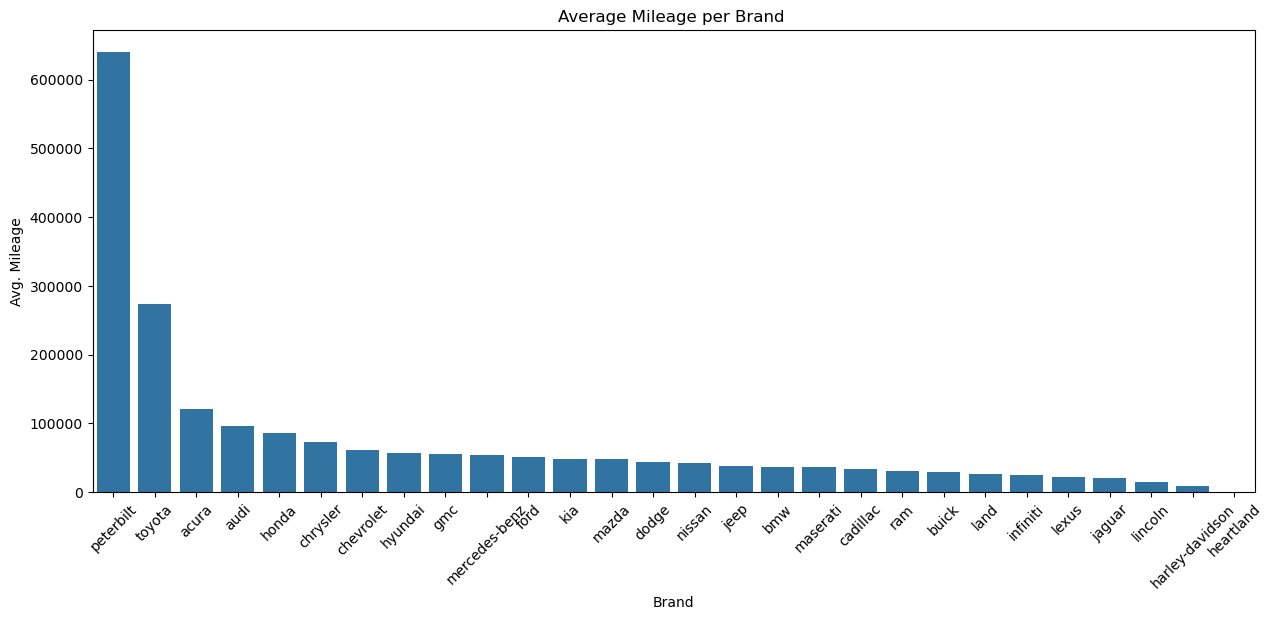

In [280]:
plt.figure(figsize = (15 , 6))

sns.barplot( x= avg_mileage_brand.index ,
y = avg_mileage_brand.values )
plt.xticks(rotation = 45)
plt.title('Average Mileage per Brand ')
plt.xlabel('Brand')
plt.ylabel('Avg. Mileage')

plt.show

# 📈 Relationship Analysis

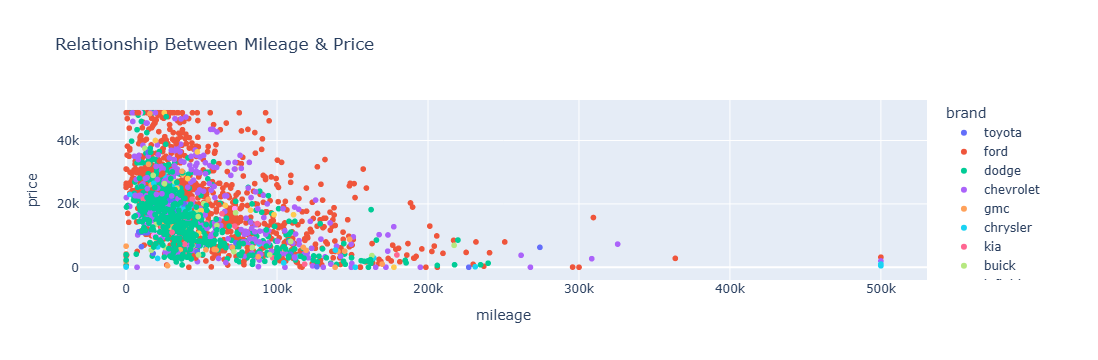

In [320]:
# Price vs Mileage
fig = px.scatter( df,
                  x = 'mileage' , 
                  y = 'price' ,
                  color = 'brand' ,
                  title = 'Relationship Between Mileage & Price')

fig.show()

In [319]:
#df[df['mileage'] > 500000]

In [316]:
#df['mileage'] = df['mileage'].clip( upper = 500000 )

 4 entries with extremely high mileage (> 500000) were capped 

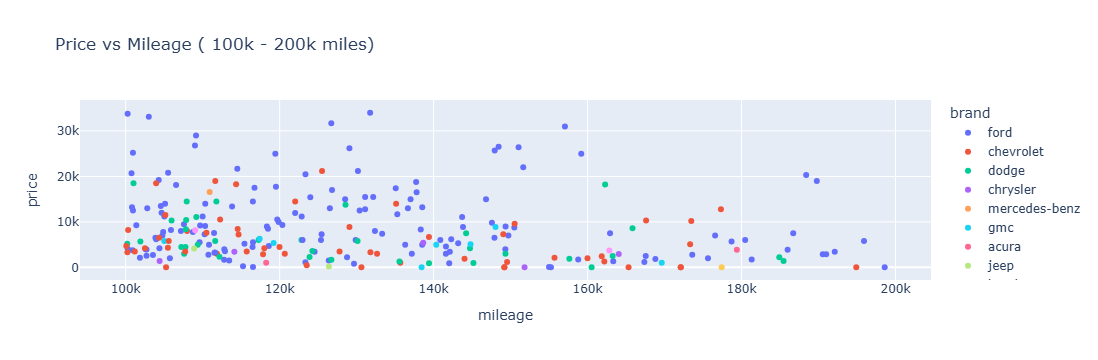

In [317]:
# Price vs Mileage
df_zoom = df[(df['mileage'] > 100000) & (df['mileage'] < 200000)]
fig = px.scatter( df_zoom,
                  x = 'mileage' , 
                  y = 'price' ,
                  color = 'brand' ,
                  title = 'Price vs Mileage ( 100k - 200k miles)')

fig.show()

# Foucusing on cars with mileage between 100k and 200 k

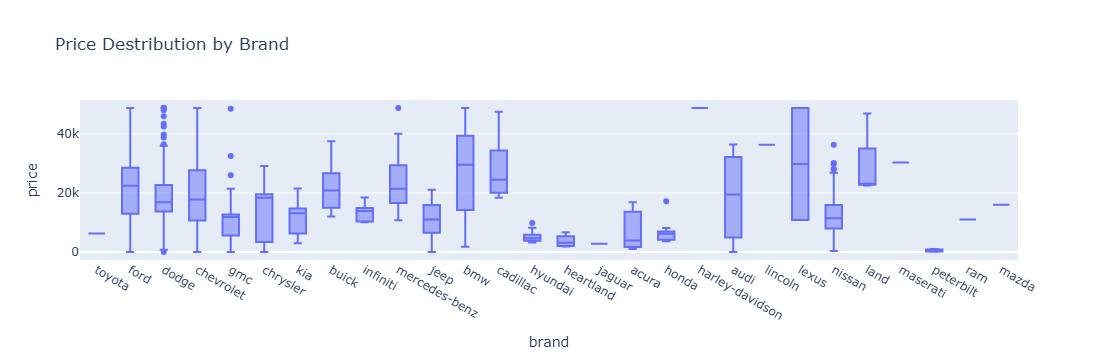

In [322]:
# Price Destribution by Brand
fig = px.box ( df , 
               x= 'brand' ,
               y= 'price' ,
               title= 'Price Destribution by Brand' )

fig.show()

# 🔝 TOP 5 BRANDS

In [331]:
# top 5 brands
top5 = df['brand'].value_counts().nlargest(5).index
print('🔝 Top 5 brands : ' , top5)

🔝 Top 5 brands :  Index(['ford', 'dodge', 'nissan', 'chevrolet', 'gmc'], dtype='object', name='brand')


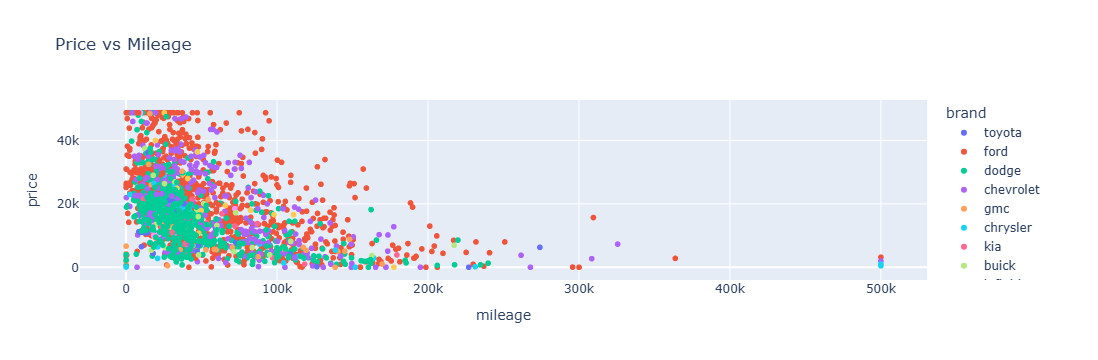

In [388]:
#Price vs Mileage 
fig = px.scatter( df,
                  x = 'mileage' , 
                  y = 'price' ,
                  color = 'brand' ,
                  title = 'Price vs Mileage')

fig.show()

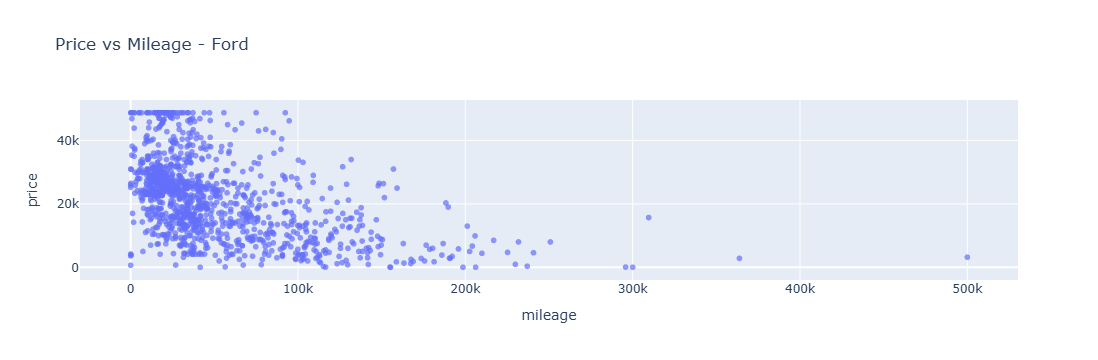

In [349]:
# TOP 1 - Ford
df_ford = df[df['brand'] == 'ford']

fig = px.scatter(
    df_ford,
    x='mileage',
    y='price',
    opacity=0.7,
    title='Price vs Mileage - Ford')

fig.show()

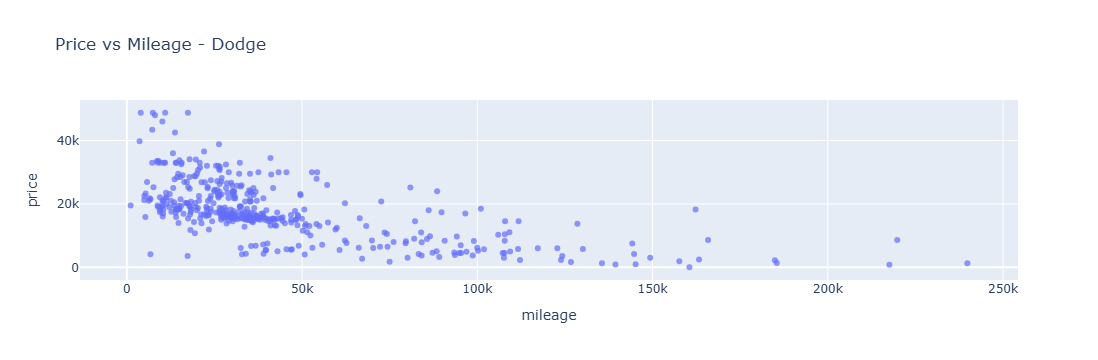

In [352]:
# TOP 2 - Dodge
df_dodge = df[df['brand'] == 'dodge']

fig = px.scatter(
    df_dodge,
    x='mileage',
    y='price',
    opacity=0.7,
    title='Price vs Mileage - Dodge')

fig.show()

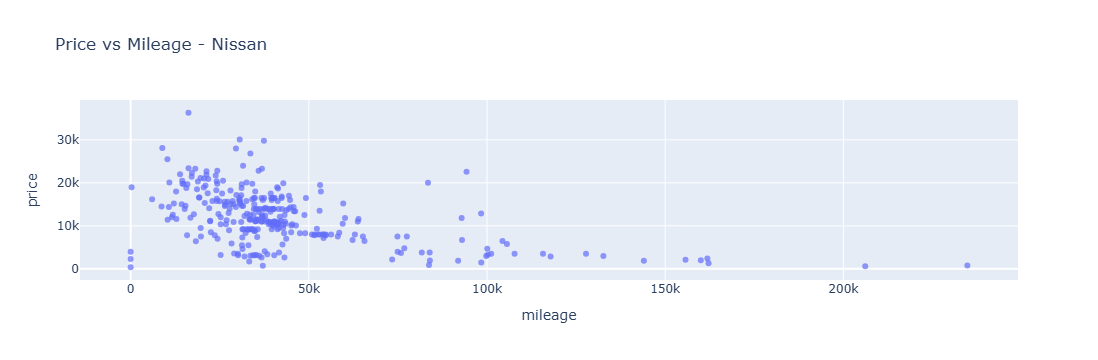

In [353]:
# TOP 3 - Nissan
df_nissan = df[df['brand'] == 'nissan']

fig = px.scatter(
    df_nissan,
    x='mileage',
    y='price',
    opacity=0.7,
    title='Price vs Mileage - Nissan')

fig.show()

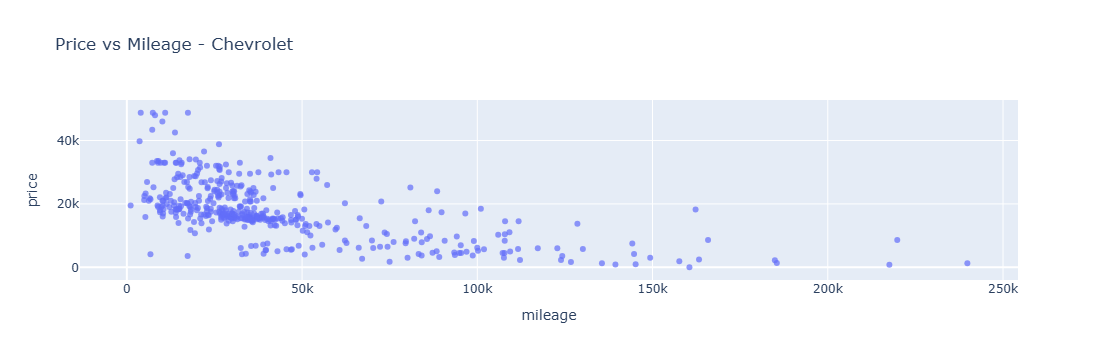

In [355]:
# TOP 4 - Chevrolet
df_chevrolet = df[df['brand'] == 'chevrolet']

fig = px.scatter(
    df_ford,
    x='mileage',
    y='price',
    opacity=0.7,
    title='Price vs Mileage - Chevrolet')

fig.show()

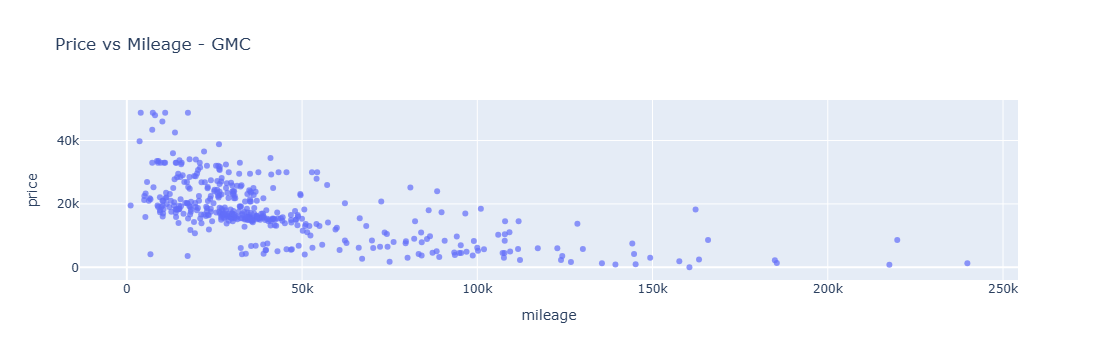

In [357]:
# TOP 5 - GMC
df_gmc = df[df['brand'] == 'gmc']

fig = px.scatter(
    df_ford,
    x='mileage',
    y='price',
    opacity=0.7,
    title='Price vs Mileage - GMC')

fig.show()

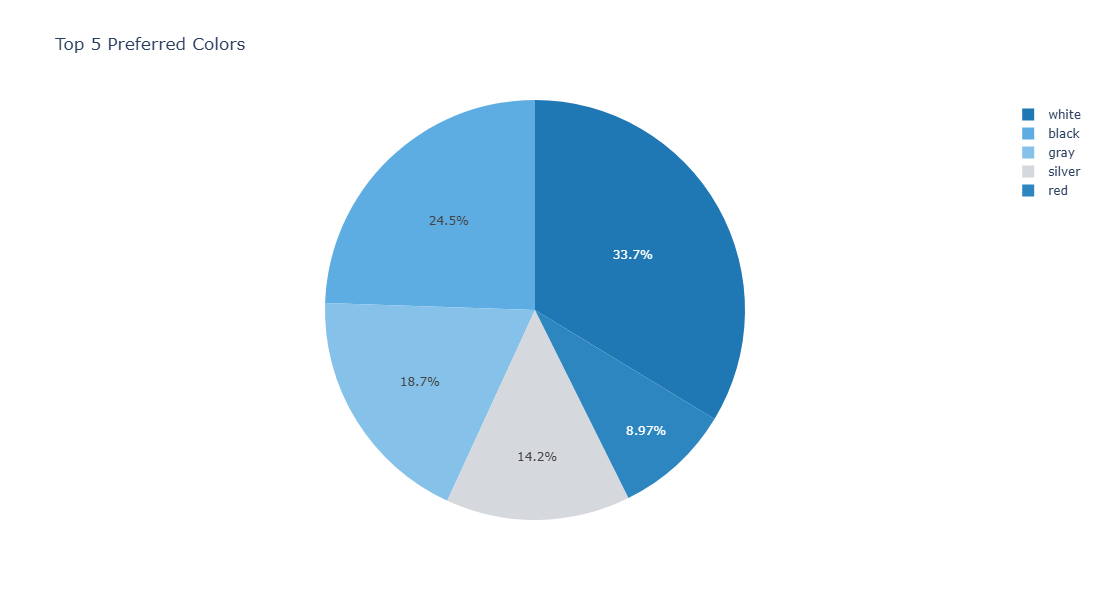

In [390]:
# Top 5 Preferred Colors
top5_colors = df['color'].value_counts().nlargest(5).reset_index()
top5_colors.columns = ['color' , 'count']
color_palette = color_palette = ['#1f77b4', '#5dade2', '#85c1e9', '#d5d8dc', '#2e86c1']
fig = px.pie(  top5_colors,
               
               values = 'count' ,
               names = 'color' ,
               title = 'Top 5 Preferred Colors',
            color_discrete_sequence = color_palette,
               width=800 ,
               height = 600
            )

fig.show()

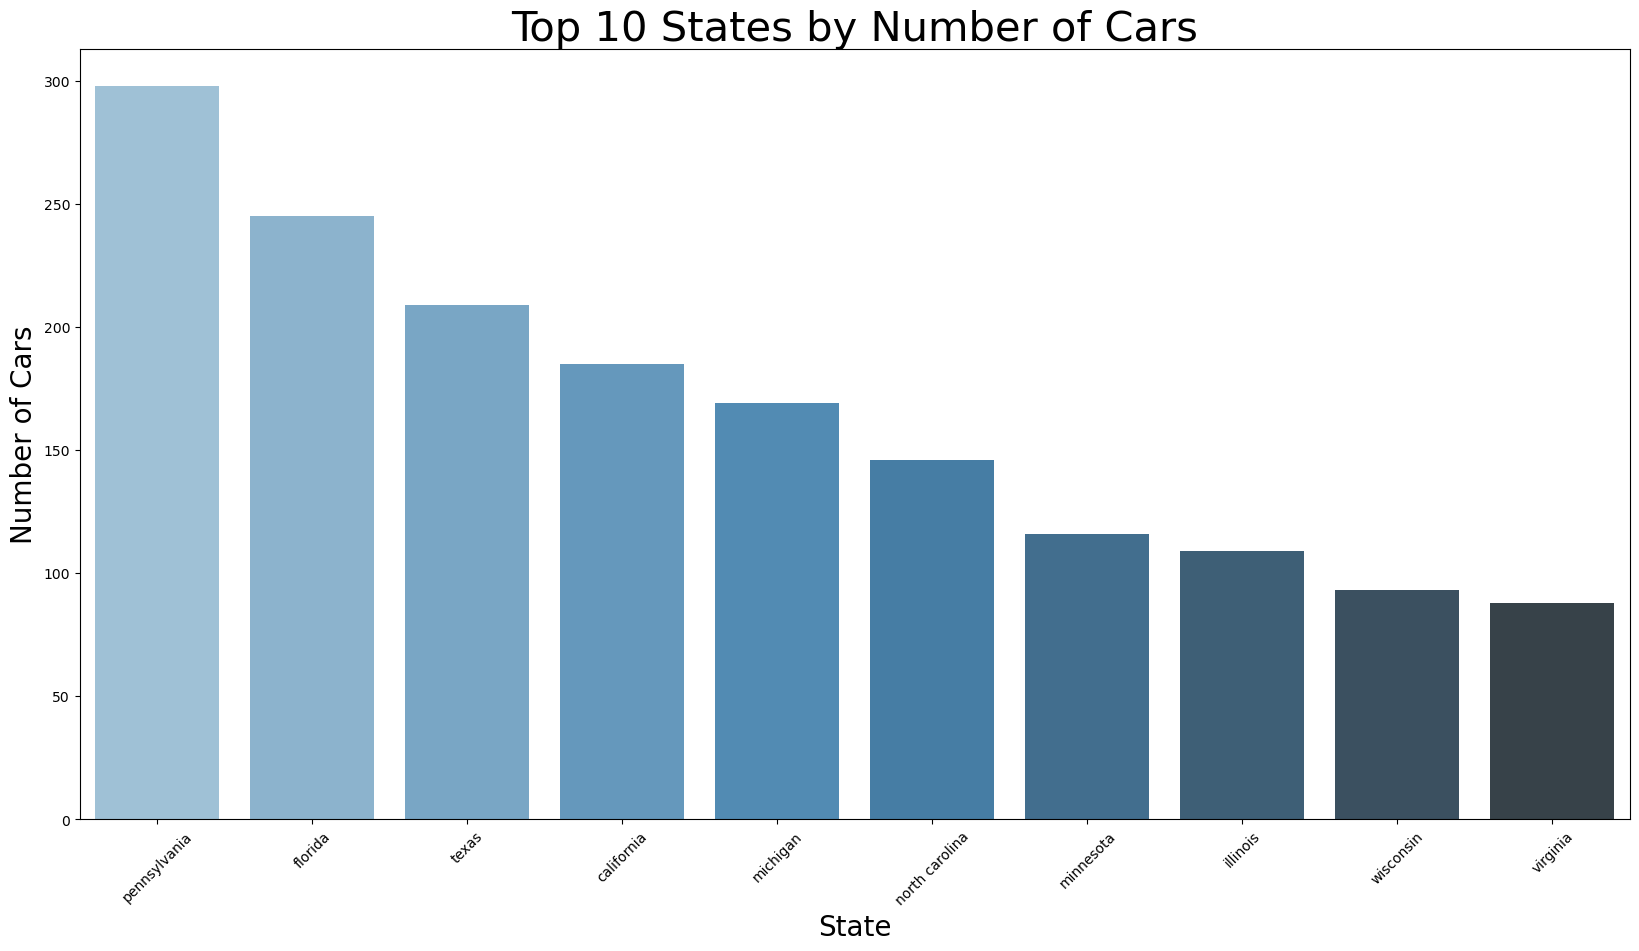

In [407]:
# Top 10 States
top_states = df['state'].value_counts().nlargest(10).reset_index()
top_states.columns = ['state', 'count']

plt.figure(figsize=(20,10))
sns.barplot(x="state", y="count", data=top_states , hue= 'state', palette="Blues_d")

plt.xlabel("State", fontsize=20)
plt.ylabel("Number of Cars", fontsize=20)
plt.title("Top 10 States by Number of Cars", fontsize=30)
plt.xticks(rotation=45)
plt.show()

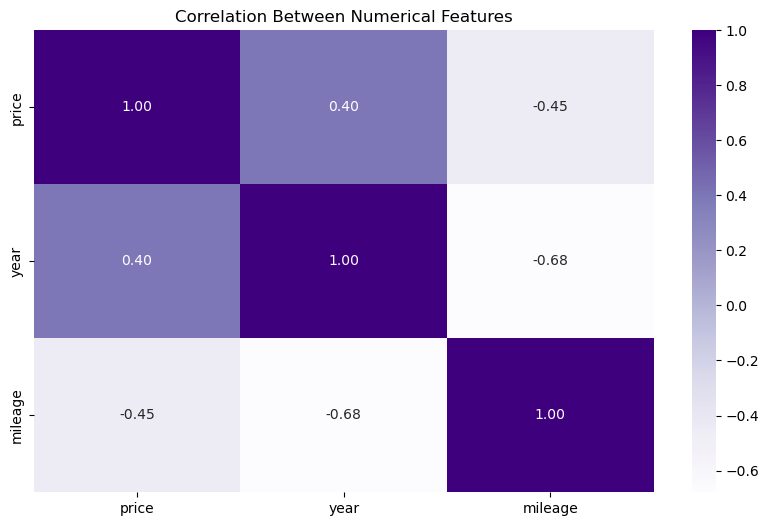

In [415]:
# Correlation Between Numerical Features
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(10,6))
corr = numeric_df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="Purples",
    fmt=".2f"
)

plt.title("Correlation Between Numerical Features")
plt.show()